In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

Step 2: Load the Dataset


In [8]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print('Shape:', df.shape)  
df.head()                  

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [10]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Step 3: Exploratory Data Analysis (EDA)


stroke
0    4861
1     249
Name: count, dtype: int64


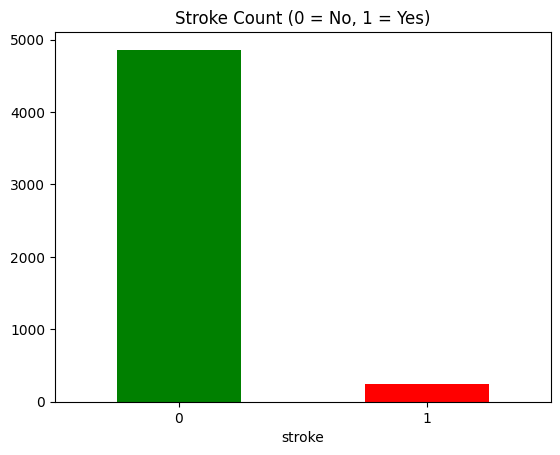

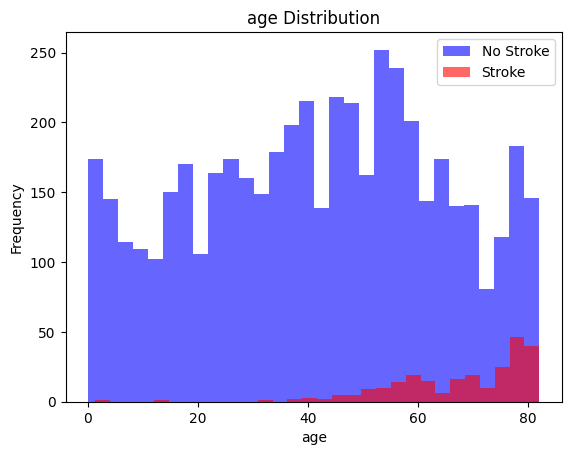

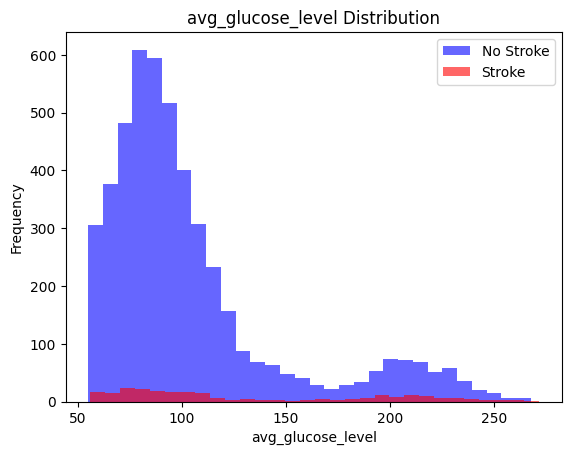

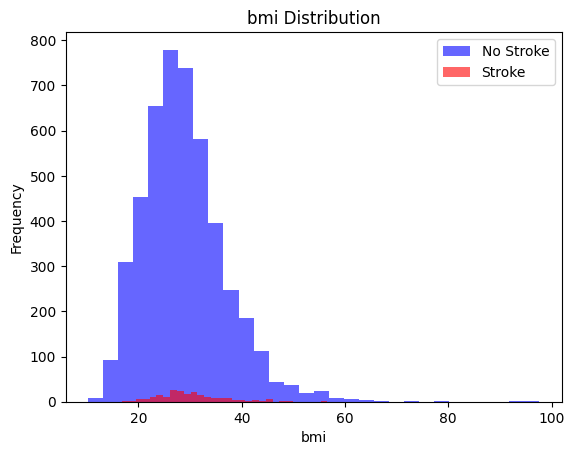

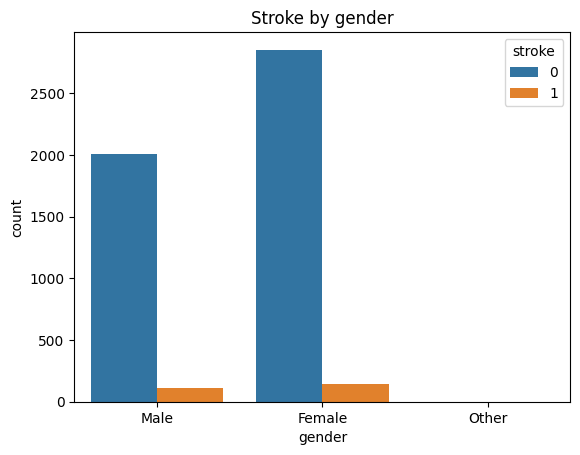

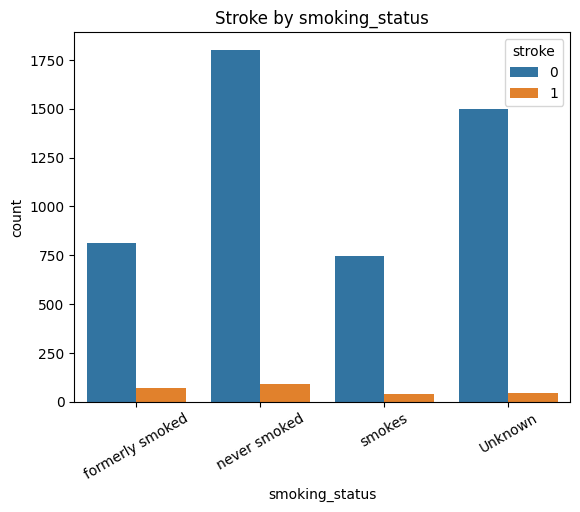

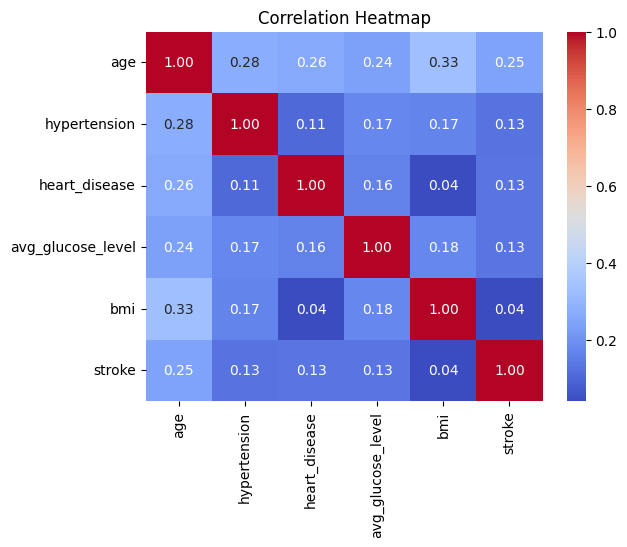

In [11]:
# Stroke count
print(df['stroke'].value_counts())
df['stroke'].value_counts().plot(kind='bar', color=['green', 'red'], rot=0, title='Stroke Count (0 = No, 1 = Yes)')
plt.show()

# Distributions: stroke vs no stroke
for col in ['age', 'avg_glucose_level', 'bmi']:
    for val, color, label in [(0, 'blue', 'No Stroke'), (1, 'red', 'Stroke')]:
        df[df['stroke'] == val][col].plot(kind='hist', alpha=0.6, bins=30, color=color, label=label)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.legend()
    plt.show()

# Categorical breakdowns
for col, rot in [('gender', 0), ('smoking_status', 30)]:
    sns.countplot(x=col, hue='stroke', data=df)
    plt.title(f'Stroke by {col}')
    plt.xticks(rotation=rot)
    plt.show()

# Correlation heatmap
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()



Step 4: data preprocessing



In [12]:
df = df.astype({
    col: 'string'
    for col in df.select_dtypes(include='object').columns
})

print(df.dtypes)

id                            int64
gender               string[python]
age                         float64
hypertension                  int64
heart_disease                 int64
ever_married         string[python]
work_type            string[python]
Residence_type       string[python]
avg_glucose_level           float64
bmi                         float64
smoking_status       string[python]
stroke                        int64
dtype: object


In [13]:
df.drop(columns=['id'], inplace=True)
print('id column dropped')


id column dropped


In [14]:
print(df.isnull().sum())


gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [15]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)
print('Missing values after fix:')
print(df.isnull().sum())


Missing values after fix:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [16]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [17]:
df = df[df['gender'] != 'Other']
print('Rows remaining:', len(df))

Rows remaining: 5109


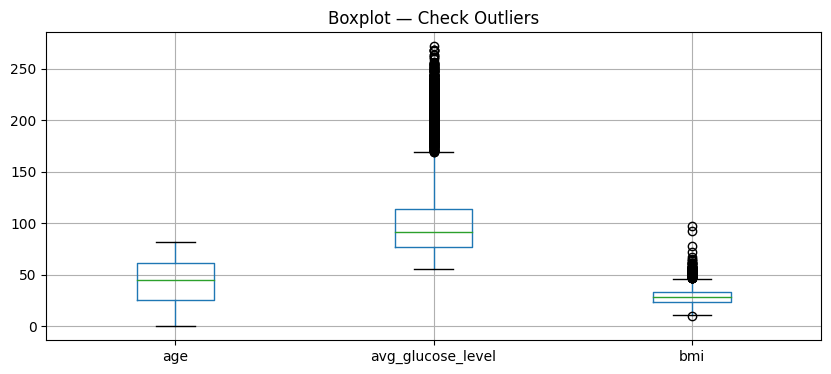

In [18]:
df[['age', 'avg_glucose_level', 'bmi']].boxplot(figsize=(10, 4))
plt.title('Boxplot — Check Outliers')
plt.show()


In [19]:
#outlier
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
df['bmi'] = df['bmi'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)


Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
df['avg_glucose_level'] = df['avg_glucose_level'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print('Outliers capped.')


Outliers capped.


In [20]:

le = LabelEncoder()

df['gender']         = le.fit_transform(df['gender'])          
df['ever_married']   = le.fit_transform(df['ever_married'])    
df['work_type']      = le.fit_transform(df['work_type'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])  
df['smoking_status'] = le.fit_transform(df['smoking_status'])

print('All text columns encoded.')
df.head()


All text columns encoded.


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,169.365,36.6,1,1
1,0,61.0,0,0,1,3,0,169.365,28.1,2,1
2,1,80.0,0,1,1,2,0,105.920,32.5,2,1
3,0,49.0,0,0,1,2,1,169.365,34.4,3,1
4,0,79.0,1,0,1,3,0,169.365,24.0,2,1


 Step 5: Feature Selection


In [21]:
X = df.drop('stroke', axis=1)
y = df['stroke']

Step 6: Train-Test Split & Handle Class Imbalance



In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test  = scaler.transform(X_test)       

Step 7: Build & Train ML Models



In [24]:
results = {}

In [25]:
#logistic regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, pred_lr)
print('Logistic Regression Accuracy:', round(results['Logistic Regression'], 4))


Logistic Regression Accuracy: 0.9511


In [26]:
#decision tree
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, pred_dt)
print('Decision Tree Accuracy:', round(results['Decision Tree'], 4))


Decision Tree Accuracy: 0.9442


In [27]:
#k-nearest neighbors
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
pred_knn = model_knn.predict(X_test)
results['KNN'] = accuracy_score(y_test, pred_knn)
print('KNN Accuracy:', round(results['KNN'], 4))


KNN Accuracy: 0.9511


In [28]:
#support vector machine
model_svm = SVC(probability=True, random_state=42)
model_svm.fit(X_train, y_train)
pred_svm = model_svm.predict(X_test)
results['SVM'] = accuracy_score(y_test, pred_svm)
print('SVM Accuracy:', round(results['SVM'], 4))


SVM Accuracy: 0.9511


In [29]:
#random forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, pred_rf)
print('Random Forest Accuracy:', round(results['Random Forest'], 4))


Random Forest Accuracy: 0.9481


In [30]:
#XGBoost
model_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)
results['XGBoost'] = accuracy_score(y_test, pred_xgb)
print('XGBoost Accuracy:', round(results['XGBoost'], 4))


XGBoost Accuracy: 0.9442


Step 8: Compare All Models

In [31]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results_df)


                 Model  Accuracy
0  Logistic Regression  0.951076
1                  KNN  0.951076
2                  SVM  0.951076
3        Random Forest  0.948141
4        Decision Tree  0.944227
5              XGBoost  0.944227


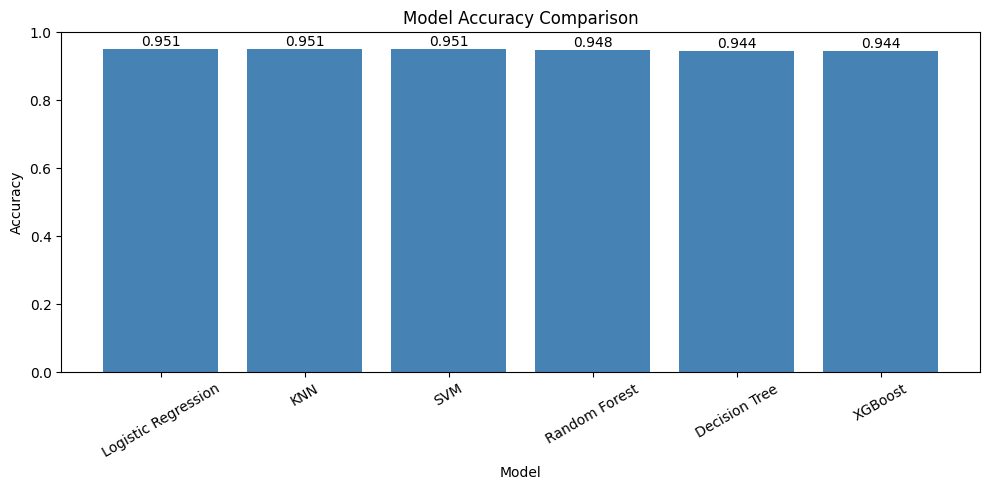

In [32]:
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='steelblue')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=30)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.tight_layout()
plt.show()


Step 9: Evaluate the Best Model 

In [33]:
# Detailed classification 
print(classification_report(y_test, pred_lr, target_names=['No Stroke', 'Stroke']))


              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



c:\Users\aalap\anaconda3\envs\tens_envo\envs\tens_gpu\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\aalap\anaconda3\envs\tens_envo\envs\tens_gpu\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\aalap\anaconda3\envs\tens_envo\envs\tens_gpu\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

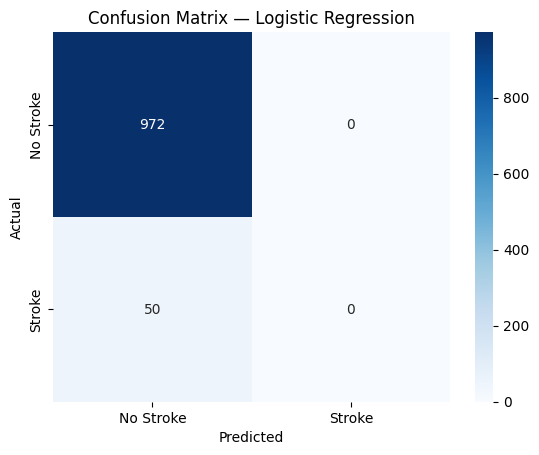

In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [35]:
prob_xgb = model_lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, prob_xgb)
print('ROC-AUC Score:', round(auc, 4))

ROC-AUC Score: 0.8367


Predict on New / Unseen Data



In [36]:
patient1 = pd.DataFrame([{
    'gender': 1,              
    'age': 72,
    'hypertension': 1,        
    'heart_disease': 1,       
    'ever_married': 1,        
    'work_type': 2,           
    'Residence_type': 1,      
    'avg_glucose_level': 200,
    'bmi': 33.0,
    'smoking_status': 1       
}])
patient2 = pd.DataFrame([{
    'gender': 0,
    'age': 29,
    'hypertension': 0,
    'heart_disease': 0,
    'ever_married': 0,
    'work_type': 2,
    'Residence_type': 0,
    'avg_glucose_level': 85,
    'bmi': 22.0,
    'smoking_status': 0
}])
patient1_scaled = scaler.transform(patient1)
patient2_scaled = scaler.transform(patient2)
pred1 = model_xgb.predict(patient1_scaled)[0]
pred2 = model_xgb.predict(patient2_scaled)[0]
print('Patient 1 (72 yrs, high risk):', 'STROKE RISK' if pred1 == 1 else 'No Stroke')
print('Patient 2 (29 yrs, healthy)  :', 'STROKE RISK' if pred2 == 1 else 'No Stroke')


Patient 1 (72 yrs, high risk): No Stroke
Patient 2 (29 yrs, healthy)  : No Stroke


Step 11: Final Conclusion


 XGBoost is Best:
- Highest accuracy and ROC-AUC score
- Handles imbalanced data well
- Works great for medical prediction tasks
